In [2]:
import squigglepy as sq
import numpy as np
from scipy.stats import lognorm

sq.set_seed(42)
np.random.seed(42)

# ==============================================
# How quarterly correlation affects cumulative share variance
# ==============================================
# A company buys 10% of chips each quarter [8%, 12%] across 16 quarters.
# With constant revenue, cumulative share = simple average of quarterly shares.
# Compare three correlation structures.

n_quarters = 16
n_sims = 10000

# --- Scenario 1: 0% correlation (independent quarters) ---
uncorr_dists = [sq.to(0.08, 0.12) for _ in range(n_quarters)]
uncorr_samples = np.array([d @ n_sims for d in uncorr_dists])  # (16, n_sims)
uncorr_avg = uncorr_samples.mean(axis=0)

# --- Scenario 2: 50% correlation across all quarters ---
corr_dists_input = tuple(sq.to(0.08, 0.12) for _ in range(n_quarters))
corr_matrix = [[1.0 if i == j else 0.5 for j in range(n_quarters)] for i in range(n_quarters)]
corr_dists = sq.correlate(corr_dists_input, corr_matrix)
corr_samples = np.array([d @ n_sims for d in corr_dists])  # (16, n_sims)
corr_avg = corr_samples.mean(axis=0)

# --- Scenario 3: yearly buckets, 50% correlated between years ---
# 4 years × 4 quarters each. Within a year, all quarters share one draw.
# Between years, the draws are 50% correlated.
n_years = 4
quarters_per_year = 4
yearly_dists = tuple(sq.to(0.08, 0.12) for _ in range(n_years))
yearly_corr = [[1.0 if i == j else 0.5 for j in range(n_years)] for i in range(n_years)]
yearly_corr_dists = sq.correlate(yearly_dists, yearly_corr)
yearly_samples = np.array([d @ n_sims for d in yearly_corr_dists])  # (4, n_sims)
# Expand: each year's sample applies to all 4 quarters in that year
yearly_expanded = np.repeat(yearly_samples, quarters_per_year, axis=0)  # (16, n_sims)
yearly_avg = yearly_expanded.mean(axis=0)

# --- Perfect correlation upper bound (closed-form) ---
# With 100% correlation, all quarters are the same draw, so cumulative avg = single draw.
# sq.to(0.08, 0.12) is lognormal with 90% CI [0.08, 0.12].
log_sigma = np.log(0.12 / 0.08) / (2 * 1.645)
median_val = np.sqrt(0.08 * 0.12)
perfect_corr_sd = median_val * np.sqrt(np.exp(log_sigma**2) - 1) * 100
# CI and IQR from the lognormal quantile function
ln_mu = np.log(median_val)
perfect_dist = lognorm(s=log_sigma, scale=np.exp(ln_mu))
perfect_p5, perfect_p25, perfect_p50, perfect_p75, perfect_p95 = [
    perfect_dist.ppf(p) * 100 for p in [0.05, 0.25, 0.50, 0.75, 0.95]
]

# --- Results ---
print("Cumulative share of revenue across 16 quarters (equal weight)")
print("Each quarter: 10% share [8%–12%]\n")

scenarios = [
    ("0% correlated (all independent)", uncorr_avg),
    ("50% correlated (all 16 quarters)", corr_avg),
    ("Yearly buckets, 50% correlated between years", yearly_avg),
]

for label, samples in scenarios:
    p5, p25, p50, p75, p95 = [np.percentile(samples, p) * 100 for p in [5, 25, 50, 75, 95]]
    sd = np.std(samples) * 100
    print(f"  {label}:")
    print(f"    Median: {p50:.2f}%  |  90% CI: [{p5:.2f}%, {p95:.2f}%]  |  IQR: [{p25:.2f}%, {p75:.2f}%]  |  SD: {sd:.2f}pp")
    print()

print(f"  100% correlated (upper bound, closed-form):")
print(f"    Median: {perfect_p50:.2f}%  |  90% CI: [{perfect_p5:.2f}%, {perfect_p95:.2f}%]  |  IQR: [{perfect_p25:.2f}%, {perfect_p75:.2f}%]  |  SD: {perfect_corr_sd:.2f}pp")
print()
print("Independent quarters wash out most uncertainty in the average.")
print("Yearly buckets preserve more variance since only 4 independent-ish draws matter.")
print("All-quarter 50% correlation is in between.")

Cumulative share of revenue across 16 quarters (equal weight)
Each quarter: 10% share [8%–12%]

  0% correlated (all independent):
    Median: 9.86%  |  90% CI: [9.38%, 10.39%]  |  IQR: [9.66%, 10.07%]  |  SD: 0.31pp

  50% correlated (all 16 quarters):
    Median: 9.83%  |  90% CI: [8.49%, 11.40%]  |  IQR: [9.27%, 10.45%]  |  SD: 0.89pp

  Yearly buckets, 50% correlated between years:
    Median: 9.83%  |  90% CI: [8.36%, 11.52%]  |  IQR: [9.21%, 10.50%]  |  SD: 0.96pp

  100% correlated (upper bound, closed-form):
    Median: 9.80%  |  90% CI: [8.00%, 12.00%]  |  IQR: [9.02%, 10.65%]  |  SD: 1.21pp

Independent quarters wash out most uncertainty in the average.
Yearly buckets preserve more variance since only 4 independent-ish draws matter.
All-quarter 50% correlation is in between.


## Cross-quarter correlation in ownership shares

Ownership shares should be correlated between quarters for both causal and epistemic reasons. Causally, procurement contracts and capex budgets create real stickiness — if Microsoft buys 25% of Nvidia's output this quarter, it's very likely to buy a similar share next quarter. Epistemically, much of our uncertainty is about the *level* (is Microsoft 18% or 25%?) rather than quarter-to-quarter noise.

Two correlation structures to consider:
- **Flat correlation**: every pair of quarters has the same correlation rho, regardless of distance. Simple but treats Q1↔Q2 the same as Q1↔Q16.
- **Autoregressive (AR(1)) correlation**: adjacent quarters are correlated at rho, and correlation decays exponentially with distance (rho^|i-j|). More realistic — nearby quarters are more similar than distant ones.

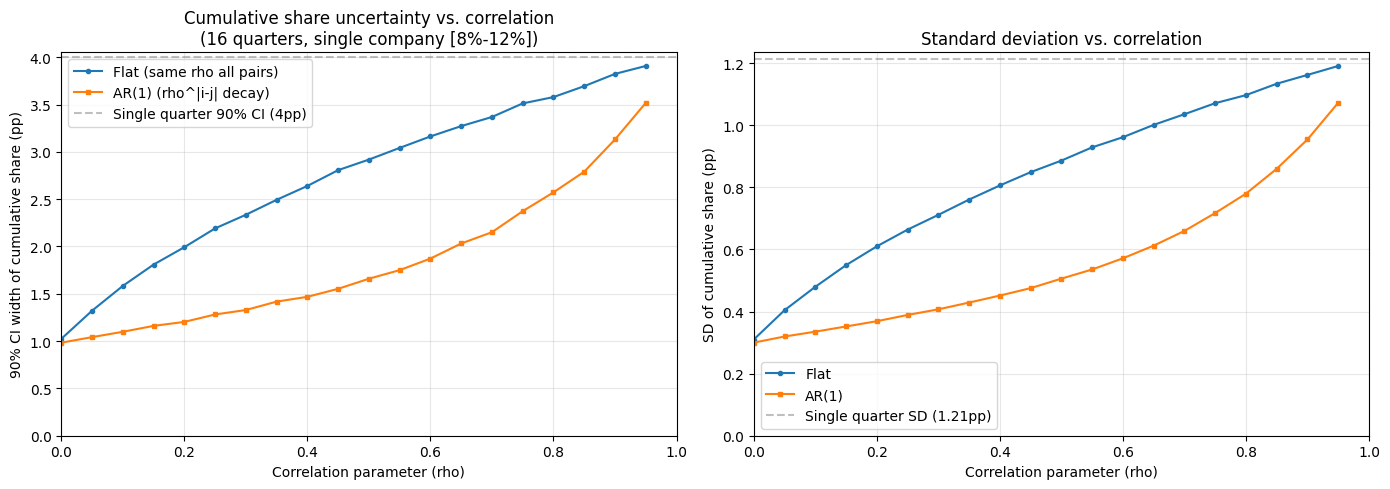


Key reference points:
  rho=0.0: Flat CI=1.02pp, AR(1) CI=0.98pp
  rho=0.5: Flat CI=2.92pp, AR(1) CI=1.66pp
  rho=0.7: Flat CI=3.37pp, AR(1) CI=2.15pp
  rho=0.9: Flat CI=3.82pp, AR(1) CI=3.13pp
  rho=1.0: Single quarter CI=4.00pp (upper bound)


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ==============================================
# Sensitivity analysis: how CI width scales with correlation
# ==============================================
# For a company with share [8%, 12%] across 16 quarters,
# sweep correlation from 0 to 1 and measure cumulative CI width.

n_quarters = 16
n_sims = 10000
# Cap at 0.99 to avoid floating-point issues with the PSD check at rho=1.0
rho_values = np.arange(0, 1.0, 0.05)

ci_widths_flat = []      # Flat correlation (same rho for all pairs)
ci_widths_ar1 = []       # AR(1): rho^|i-j| decay
sd_flat = []
sd_ar1 = []

for rho in rho_values:
    # --- Flat correlation ---
    dists_flat = tuple(sq.to(0.08, 0.12) for _ in range(n_quarters))
    flat_matrix = [[1.0 if i == j else float(rho) for j in range(n_quarters)] for i in range(n_quarters)]
    corr_flat = sq.correlate(dists_flat, flat_matrix)
    samples_flat = np.array([d @ n_sims for d in corr_flat])
    avg_flat = samples_flat.mean(axis=0)
    p5_f, p95_f = np.percentile(avg_flat, 5), np.percentile(avg_flat, 95)
    ci_widths_flat.append((p95_f - p5_f) * 100)
    sd_flat.append(np.std(avg_flat) * 100)

    # --- AR(1) correlation: rho^|i-j| ---
    dists_ar1 = tuple(sq.to(0.08, 0.12) for _ in range(n_quarters))
    ar1_matrix = [[float(rho) ** abs(i - j) for j in range(n_quarters)] for i in range(n_quarters)]
    corr_ar1 = sq.correlate(dists_ar1, ar1_matrix)
    samples_ar1 = np.array([d @ n_sims for d in corr_ar1])
    avg_ar1 = samples_ar1.mean(axis=0)
    p5_a, p95_a = np.percentile(avg_ar1, 5), np.percentile(avg_ar1, 95)
    ci_widths_ar1.append((p95_a - p5_a) * 100)
    sd_ar1.append(np.std(avg_ar1) * 100)

# Theoretical bounds
# rho=0: SD of mean of 16 iid lognormals ≈ single_sd / sqrt(16)
# rho=1: SD of mean = single_sd (no averaging benefit)
single_sd = perfect_corr_sd  # From the closed-form above

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: CI width vs rho
ax1.plot(rho_values, ci_widths_flat, 'o-', label='Flat (same rho all pairs)', markersize=3)
ax1.plot(rho_values, ci_widths_ar1, 's-', label='AR(1) (rho^|i-j| decay)', markersize=3)
ax1.axhline(y=4.0, color='gray', linestyle='--', alpha=0.5, label='Single quarter 90% CI (4pp)')
ax1.set_xlabel('Correlation parameter (rho)')
ax1.set_ylabel('90% CI width of cumulative share (pp)')
ax1.set_title('Cumulative share uncertainty vs. correlation\n(16 quarters, single company [8%-12%])')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, None)

# Right: SD vs rho
ax2.plot(rho_values, sd_flat, 'o-', label='Flat', markersize=3)
ax2.plot(rho_values, sd_ar1, 's-', label='AR(1)', markersize=3)
ax2.axhline(y=single_sd, color='gray', linestyle='--', alpha=0.5, label=f'Single quarter SD ({single_sd:.2f}pp)')
ax2.set_xlabel('Correlation parameter (rho)')
ax2.set_ylabel('SD of cumulative share (pp)')
ax2.set_title('Standard deviation vs. correlation')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)
ax2.set_ylim(0, None)

plt.tight_layout()
# plt.savefig('visualizations/correlation_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey reference points:")
print(f"  rho=0.0: Flat CI={ci_widths_flat[0]:.2f}pp, AR(1) CI={ci_widths_ar1[0]:.2f}pp")
print(f"  rho=0.5: Flat CI={ci_widths_flat[10]:.2f}pp, AR(1) CI={ci_widths_ar1[10]:.2f}pp")
print(f"  rho=0.7: Flat CI={ci_widths_flat[14]:.2f}pp, AR(1) CI={ci_widths_ar1[14]:.2f}pp")
print(f"  rho=0.9: Flat CI={ci_widths_flat[18]:.2f}pp, AR(1) CI={ci_widths_ar1[18]:.2f}pp")
print(f"  rho=1.0: Single quarter CI=4.00pp (upper bound)")

## Reverse calibration: what should the cumulative CI look like?

Instead of picking a correlation and seeing what CI falls out, think about it from the other direction: what cumulative uncertainty feels right, and what correlation does that imply?

**Calibration question**: If a company's quarterly share is [8%, 12%] each quarter, what should the 90% CI on their *cumulative* share be?

- If you think the cumulative share should also be [8%, 12%] — you believe the uncertainty is fully about the level, not the trajectory. That's ~100% correlation.
- If you think the cumulative share should be [9.4%, 10.4%] — you believe quarterly noise averages out almost completely. That's ~0% correlation.
- A plausible middle ground: cumulative CI of [8.5%, 11.5%] (3pp wide vs 4pp single quarter). That implies ~70-80% flat correlation, or ~90% AR(1).

In [5]:
# ==============================================
# Reverse calibration: map target CI width → required correlation
# ==============================================
# Use the sweep data from above to interpolate

target_ci_widths = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

print("Target cumulative 90% CI width → required correlation parameter")
print(f"(Single-quarter CI width: 4.0pp)\n")
print(f"{'Target CI (pp)':>15}  {'Flat rho':>10}  {'AR(1) rho':>10}")
print("-" * 40)

for target in target_ci_widths:
    # Interpolate: CI width is monotonically increasing with rho
    flat_rho = np.interp(target, ci_widths_flat, rho_values)
    ar1_rho = np.interp(target, ci_widths_ar1, rho_values)
    flat_str = f"{flat_rho:.2f}" if target <= max(ci_widths_flat) else ">0.99"
    ar1_str = f"{ar1_rho:.2f}" if target <= max(ci_widths_ar1) else ">0.99"
    print(f"{target:>15.1f}  {flat_str:>10}  {ar1_str:>10}")

print(f"\nFor reference, the current model uses flat rho=0.50")
print(f"CI width at flat rho=0.50: ~{ci_widths_flat[10]:.1f}pp")

Target cumulative 90% CI width → required correlation parameter
(Single-quarter CI width: 4.0pp)

 Target CI (pp)    Flat rho   AR(1) rho
----------------------------------------
            1.0        0.00        0.01
            1.5        0.08        0.42
            2.0        0.20        0.64
            2.5        0.35        0.78
            3.0        0.53        0.88
            3.5        0.75        0.95

For reference, the current model uses flat rho=0.50
CI width at flat rho=0.50: ~2.9pp


## What do the sample paths actually look like?

Below: 20 sample paths of a company's quarterly share under different correlation structures. This shows the *trajectory* of share over time in each Monte Carlo draw, which helps build intuition about whether the model "feels right."

With low correlation, each quarter is nearly independent — the path looks noisy and jumps around. With high AR(1) correlation, paths are smooth and "sticky" — if a company starts high, it tends to stay high for a while before drifting.

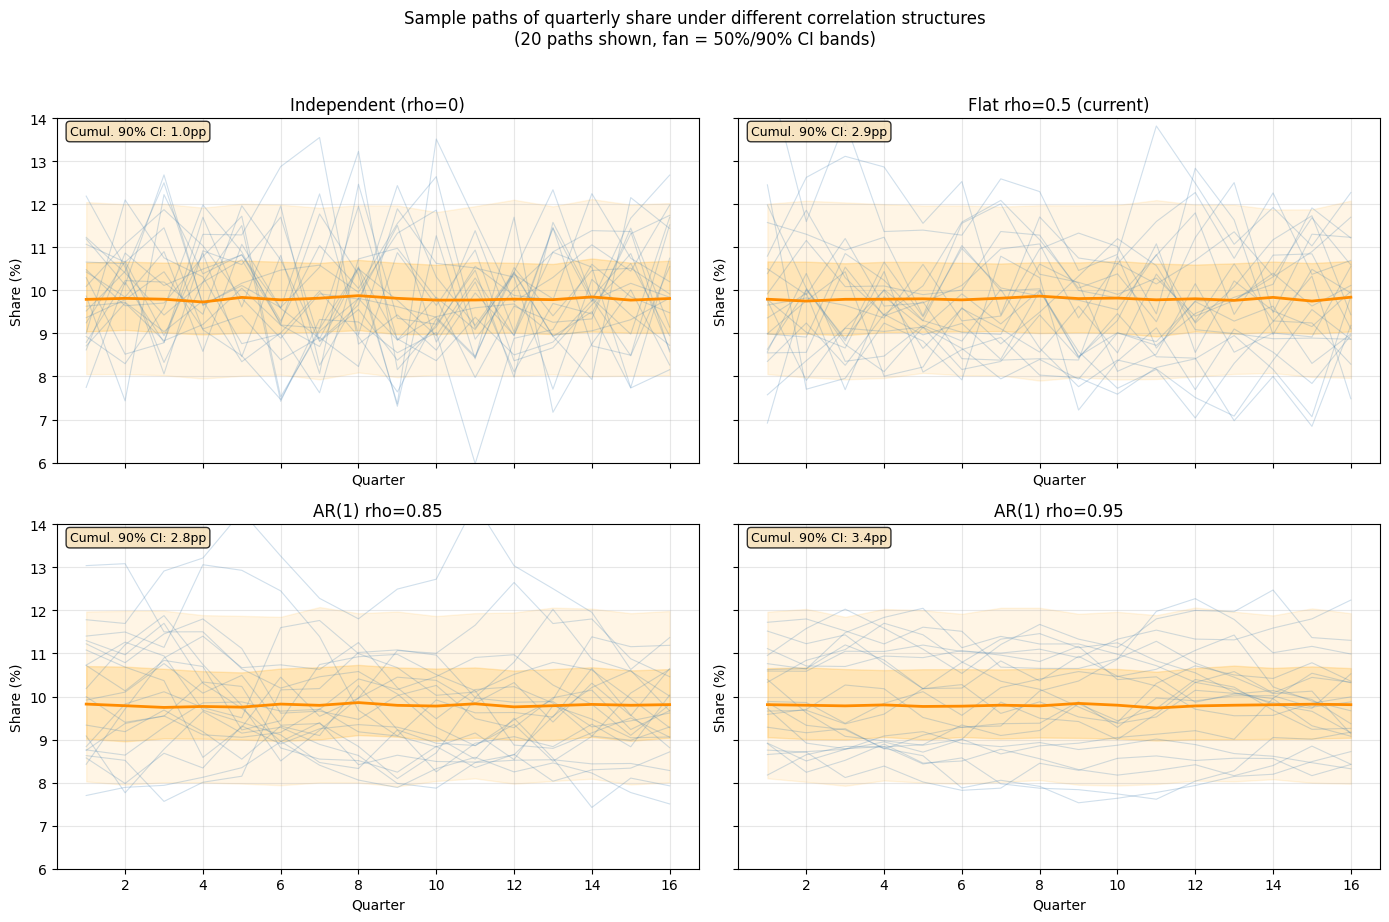

In [ ]:
# ==============================================
# Sample paths: what do trajectories look like under each structure?
# ==============================================
n_paths = 20
n_sims_paths = 2000
quarter_x = np.arange(1, n_quarters + 1)

configs = [
    ('Independent (rho=0)', 0.0, 'flat'),
    ('Flat rho=0.5 (current)', 0.5, 'flat'),
    ('AR(1) rho=0.85', 0.85, 'ar1'),
    ('AR(1) rho=0.95', 0.95, 'ar1'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)

for ax, (title, rho, structure) in zip(axes.flatten(), configs):
    dists = tuple(sq.to(0.08, 0.12) for _ in range(n_quarters))
    if structure == 'flat':
        matrix = [[1.0 if i == j else rho for j in range(n_quarters)] for i in range(n_quarters)]
    else:
        matrix = [[rho ** abs(i - j) for j in range(n_quarters)] for i in range(n_quarters)]

    corr_d = sq.correlate(dists, matrix)
    all_samples = np.array([d @ n_sims_paths for d in corr_d])  # (16, n_sims)

    # Plot sample paths
    for i in range(n_paths):
        ax.plot(quarter_x, all_samples[:, i] * 100, alpha=0.25, linewidth=0.8, color='steelblue')

    # Plot percentile bands
    p5 = np.percentile(all_samples, 5, axis=1) * 100
    p25 = np.percentile(all_samples, 25, axis=1) * 100
    p50 = np.percentile(all_samples, 50, axis=1) * 100
    p75 = np.percentile(all_samples, 75, axis=1) * 100
    p95 = np.percentile(all_samples, 95, axis=1) * 100

    ax.fill_between(quarter_x, p5, p95, alpha=0.1, color='orange')
    ax.fill_between(quarter_x, p25, p75, alpha=0.2, color='orange')
    ax.plot(quarter_x, p50, color='darkorange', linewidth=2, label='Median')

    ax.set_title(title)
    ax.set_ylabel('Share (%)')
    ax.set_xlabel('Quarter')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(6, 14)

    # Show cumulative average CI
    cum_avg = all_samples.mean(axis=0)
    ci_w = (np.percentile(cum_avg, 95) - np.percentile(cum_avg, 5)) * 100
    ax.text(0.02, 0.98, f'Cumul. 90% CI: {ci_w:.1f}pp',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Sample paths of quarterly share under different correlation structures\n'
             '(20 paths shown, fan = 50%/90% CI bands)', y=1.02)
plt.tight_layout()
plt.show()

## When does flat vs autoregressive matter?

Flat and AR(1) correlation produce similar cumulative uncertainty when calibrated to the same SD (e.g., flat rho=0.5 ≈ AR(1) rho=0.85). The choice between them matters mainly for:

- **Per-quarter or short-window estimates**: AR(1) keeps adjacent quarters tightly linked, so zooming into a specific quarter or year gives more realistic uncertainty. Flat correlation makes neighboring quarters less correlated than they should be.
- **Year-over-year changes or trend analysis**: AR(1) makes short-run differences small and long-run differences large. Flat correlation gives the same variance structure for all time gaps.
- **Conditioning on partial data**: With AR(1), knowing recent quarters strongly constrains the near future but barely constrains years out. With flat, every quarter is equally informative about every other.

For **cumulative totals across all quarters** — which is the main output of the ownership model — the two structures are nearly interchangeable at matched SD. The more important calibration question is just whether the resulting cumulative CI width is the right size.